# The chain rule, Jacobians, and directions

CPU companion; no accelerator is required. TPU execution not validated.

- Compute a small Jacobian by hand and connect forward sensitivities to reverse-mode gradients.
- Build a Jacobian one entry at a time
- Push an input direction forward
- Pull output sensitivity backward
- Check both sides of the same calculation

One model input can affect several outputs. How does a small input change move those outputs, and how does a loss send sensitivity back? We will work through one tiny vector function before asking JAX to do the same calculation.

## The idea

A Jacobian collects how each output responds to each input. We often need its action on a direction rather than the full matrix. Forward products move input perturbations to output perturbations; reverse products bring output sensitivities back to inputs.

## Follow one direction through a Jacobian

Take $J=[[4,1],[3,2]]$ and input direction $v=[1,-1]$. Multiplication gives $Jv=[3,1]$. This predicts the first-order output change when we move a small distance along that direction.

For output sensitivity $u=[2,-1]$, the reverse product is $J^Tu=[5,0]$. These vectors live in different spaces even though both happen to have two entries in this example. Use unequal input/output dimensions in a follow-up test so equal lengths cannot hide a transpose mistake.

There is a useful independent agreement: $u^T(Jv)=5$ and $(J^Tu)^Tv=5$. This checks the relationship between forward and reverse products without requiring you to inspect every Jacobian entry.

### Pause and reason

Why should we label the input and output spaces even for a square Jacobian?

<details><summary>Compare your reasoning</summary>

Equal dimensions can hide an incorrect orientation. The labels explain whether a vector is an input direction or output sensitivity and therefore which product is meaningful.

</details>

## Build a Jacobian one entry at a time

Let $f(x)=(x_0^2+x_1,\;x_0x_1)$, where $x=(x_0,x_1)$. The first output changes at rates $2x_0$ and $1$; the second changes at rates $x_1$ and $x_0$. Rows describe outputs, columns describe inputs. At $x=(2,3)$, the output is $(7,6)$ and the Jacobian is $J=\begin{pmatrix}4&1\\3&2\end{pmatrix}$.

$$
J_{ij}=\frac{\partial f_i}{\partial x_j},\qquad J\in\mathbb{R}^{m\times d}\ \text{for}\ f:\mathbb{R}^d\to\mathbb{R}^m
$$

## Push an input direction forward

Choose $v=(1,-1)$. A small move $\varepsilon v$ in the input changes the output by approximately $\varepsilon Jv$. Here $Jv=(3,1)$: the first output moves three times as fast as the second along this direction. `jax.jvp` returns both the ordinary output and this directional sensitivity. It can compute the product without storing the full Jacobian.

$$
f(x+\varepsilon v)\approx f(x)+\varepsilon Jv
$$

## Pull output sensitivity backward

Suppose the scalar loss is $L(x)=\tfrac12\|f(x)\|_2^2$. Its derivative with respect to the outputs is $c=f(x)=(7,6)$. The chain rule gives $\nabla_x L=J^\mathsf{T}c=(46,19)$. `jax.vjp` returns the output and a pullback function. Passing $c$ into that function returns input sensitivities. The pullback result is a tuple because a function can have several inputs.

$$
\nabla_x L=J^\mathsf{T}\nabla_f L
$$

## Check both sides of the same calculation

The identity $c^\mathsf{T}(Jv)=v^\mathsf{T}(J^\mathsf{T}c)$ checks that forward and reverse products agree. We also compare against the hand matrix and central differences so our evidence is not only two autodiff APIs agreeing. `jax.grad` needs a scalar output; use a Jacobian or a selected output direction for a vector function. These local derivatives do not describe a large move exactly.

## Write the vector function

Create main.py. Define the function, its input and the hand-derived Jacobian.

In [1]:
import jax
import jax.numpy as jnp

def f(x):
    return jnp.array([x[0] ** 2 + x[1], x[0] * x[1]])
x = jnp.array([2.0, 3.0])
v = jnp.array([1.0, -1.0])
J = jnp.array([[4.0, 1.0], [3.0, 2.0]])
assert jnp.allclose(f(x), jnp.array([7.0, 6.0]))

The matrix is written from the derivatives, not obtained from an autodiff call.

## Push a direction and pull a sensitivity

Append these two transformations; predict both products first.

In [2]:
out, jv = jax.jvp(f, (x,), (v,))
_, pullback = jax.vjp(f, x)
c = out
jt_c = pullback(c)[0]
assert jnp.allclose(jv, jnp.array([3.0, 1.0]))
assert jnp.allclose(jt_c, jnp.array([46.0, 19.0]))

Forward mode follows an input direction; reverse mode starts with output sensitivity.

## Connect to a scalar loss

Append the scalar objective and independent matrix checks, then run python main.py.

In [3]:
def loss(x):
    return 0.5 * jnp.sum(f(x) ** 2)
assert jnp.allclose(jax.jacfwd(f)(x), J)
assert jnp.allclose(jax.grad(loss)(x), J.T @ c)
assert jnp.allclose(jnp.dot(c, jv), jnp.dot(v, jt_c))
print('Jv / loss gradient:', jv, jt_c)

Jv / loss gradient: [3. 1.] [46. 19.]


Both routes give directional loss derivative $27$.

## Run the example

In [4]:
import jax
import jax.numpy as jnp

def f(x):
    return jnp.array([x[0] ** 2 + x[1], x[0] * x[1]])
x = jnp.array([2.0, 3.0])
v = jnp.array([1.0, -1.0])
J = jnp.array([[4.0, 1.0], [3.0, 2.0]])
assert jnp.allclose(f(x), jnp.array([7.0, 6.0]))

out, jv = jax.jvp(f, (x,), (v,))
_, pullback = jax.vjp(f, x)
c = out
jt_c = pullback(c)[0]
assert jnp.allclose(jv, jnp.array([3.0, 1.0]))
assert jnp.allclose(jt_c, jnp.array([46.0, 19.0]))

def loss(x):
    return 0.5 * jnp.sum(f(x) ** 2)
assert jnp.allclose(jax.jacfwd(f)(x), J)
assert jnp.allclose(jax.grad(loss)(x), J.T @ c)
assert jnp.allclose(jnp.dot(c, jv), jnp.dot(v, jt_c))
print('Jv / loss gradient:', jv, jt_c)

Jv / loss gradient: [3. 1.] [46. 19.]


Expected: Forward product $[3,1]$, reverse product $[46,19]$, directional loss derivative $27$.

## A Jacobian maps inputs to output sensitivities

Predict: Which output is more sensitive to the first input at $(2,3)$?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'heatmap', 'values': jax.jacfwd(f)(x).tolist(), 'rows': ['output 0', 'output 1'], 'columns': ['input 0', 'input 1'], 'unit': 'partial derivative'}

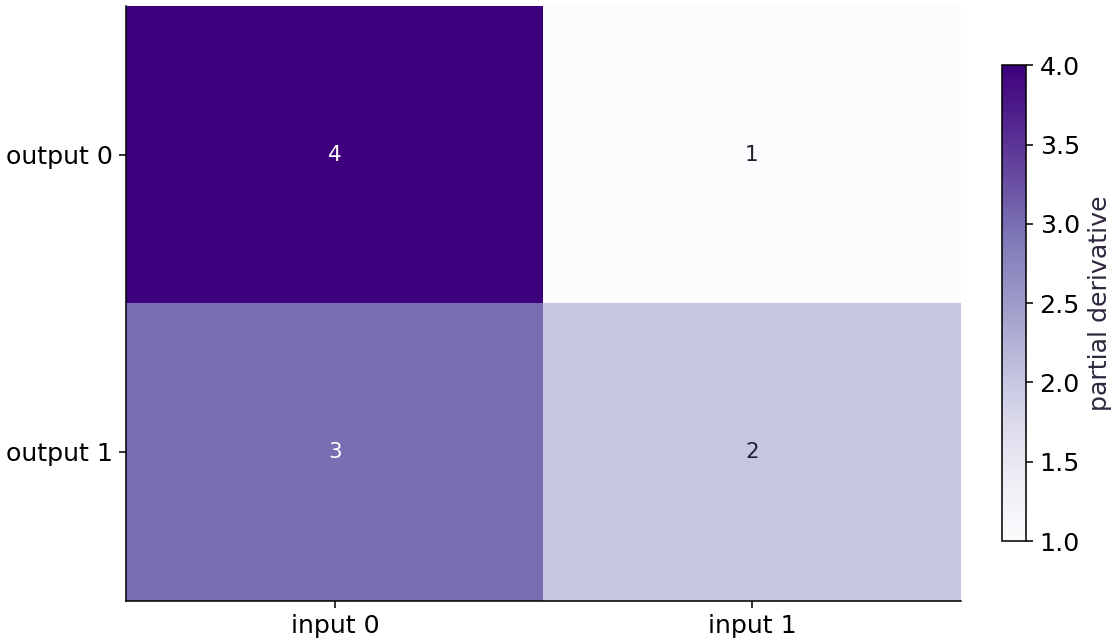

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Rows identify output coordinates and columns identify input coordinates. Each cell is a partial derivative evaluated at the example input $(2,3)$. The matrix is $J=\begin{pmatrix}4&1\\3&2\end{pmatrix}$, and darker cells indicate larger positive sensitivity here.

Read down the first column: a small increase in input $0$, holding input $1$ fixed, changes the two outputs by approximately $4$ and $3$ times that increase. Read across the first row to see how both inputs influence output $0$.

### Connect it to the computation

For a joint input change in direction $v=(1,-1)$, multiply the whole matrix by that direction: $Jv=(3,1)$. The second input’s decrease offsets some of the first input’s increase. Looking only at the darkest cell would miss that interaction.

These are local sensitivities, not model weights, probabilities, or final output values. The entries can change at another input. To check the interpretation, take a small step $\epsilon v$ and compare the output change with $\epsilon Jv$.

## Check a finite input move

Predict: Does the central difference along $v$ agree with $Jv$ at step $0.01$?

In [7]:
h = 0.01
fd = (f(x + h * v) - f(x - h * v)) / (2 * h)
assert jnp.allclose(fd, J @ v, atol=0.0001, rtol=0.0001)

Expected: The finite-direction and hand-matrix results agree within float32 tolerance.

A numerical perturbation provides a check independent of autodiff.

## Change the point

Predict: At $x=(0,1)$, which Jacobian entries change?

In [8]:
x2 = jnp.array([0.0, 1.0])
J2 = jnp.array([[0.0, 1.0], [1.0, 0.0]])
assert jnp.allclose(jax.jacrev(f)(x2), J2)
assert jnp.allclose(jax.jvp(f, (x2,), (v,))[1], J2 @ v)

Expected: The new Jacobian swaps the direction coordinates.

The Jacobian describes sensitivity at the current point; it is not generally constant.

## Your exercise

Replace the scalar loss by $L(x)=f_0(x)+2f_1(x)$. Predict its gradient at $(2,3)$ before using `grad`.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
def weighted_loss(x):
    return f(x)[0] + 2 * f(x)[1]
assert jnp.allclose(jax.grad(weighted_loss)(x), jnp.array([10.0, 5.0]))

## Find the broken derivative path · Transfer / diagnosis

A colleague wraps the first input in `jax.lax.stop_gradient`. The forward outputs are unchanged. Show why the gradient no longer matches the intended mathematical function.

Hint: Compare the derivative of the sum of outputs with $J^\mathsf{T}(1,1)$.

In [11]:
# Write your attempt here.

## Reference reasoning

Equal forward values do not imply equal differentiation behavior when derivative rules are deliberately changed.

In [12]:
def detached(x):
    a = jax.lax.stop_gradient(x[0])
    return jnp.array([a * a + x[1], a * x[1]])
assert jnp.allclose(detached(x), f(x))
assert jnp.allclose(jax.grad(lambda z: jnp.sum(detached(z)))(x), jnp.array([0.0, 3.0]))
assert jnp.allclose(jax.grad(lambda z: jnp.sum(f(z)))(x), jnp.array([7.0, 3.0]))

## Transfer to unequal dimensions · Transfer / diagnosis

For a matrix $A\in\mathbb{R}^{3\times2}$, check that the VJP of $Ax$ maps an output sensitivity of length $3$ into a vector of length $2$.

Hint: The reference is $A^\mathsf{T}c$, not $Ac$.

In [13]:
# Write your attempt here.

## Reference reasoning

Unequal input and output dimensions make a mistaken transpose visible.

In [14]:
A = jnp.array([[1.0, 0.0], [0.0, 2.0], [1.0, 1.0]])
c3 = jnp.array([1.0, -1.0, 2.0])
_, back = jax.vjp(lambda z: A @ z, x)
assert back(c3)[0].shape == (2,)
assert jnp.allclose(back(c3)[0], jnp.array([3.0, 0.0]))

## Checkpoint

Which object does a reverse-mode pullback map to input sensitivity?

1. An output sensitivity vector
2. An arbitrary input direction
3. Only a scalar learning rate

## Diagnose

If shapes fail, write output-by-input Jacobian dimensions on paper. If values match but derivatives do not, inspect stop_gradient, indexing, nondifferentiable operations and the scalar loss definition.

## Evidence

Keep the handwritten Jacobian, JVP and VJP checks, adjoint identity, finite-direction check and stop-gradient diagnosis.

## Carry forward

- A numerical perturbation provides a check independent of autodiff.
- The Jacobian describes sensitivity at the current point; it is not generally constant.

## Primary references

- [JAX autodiff cookbook: JVPs and VJPs](https://docs.jax.dev/en/latest/301/cookbook.html)